In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import shutil
import pickle

from opencv_tools import opencv_tools # 匯入封裝的功能

### 21-2-4 訓練範例：使用 LBPH 方法進行人臉模型訓練

In [2]:
def get_images_and_labels(dataset_path, detector):
    face_samples = []  # 儲存裁切後的人臉影像
    ids = []           # 儲存每張人臉對應的整數 ID
    name_to_id = {}    # 人名 → ID 的對應表
    id_to_name = {}    # ID → 人名的對應表（辨識時用來還原名稱）
    current_id = 0

    for person_name in sorted(os.listdir(dataset_path)):
        person_path = os.path.join(dataset_path, person_name)
        if not os.path.isdir(person_path):
            continue

        # 為每位人物分配唯一的整數 ID，LBPH 只接受數字標籤
        name_to_id[person_name] = current_id
        id_to_name[current_id] = person_name
        current_id += 1
        person_id = name_to_id[person_name]

        for image_name in os.listdir(person_path):
            image_path = os.path.join(person_path, image_name)
            # LBPH 以灰階影像進行訓練，讀取時直接轉換
            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

            # 偵測人臉位置，回傳每張臉的方框座標 (x, y, w, h)
            faces = detector.detectMultiScale(img)
            for (x, y, w, h) in faces:
                # 根據方框座標裁切出人臉區域並收集
                face_samples.append(img[y:y+h, x:x+w])
                ids.append(person_id)

    return face_samples, ids, id_to_name

* 主程式流程

In [3]:
# --- 設定區 ---
CASCADE_PATH = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
DATASET_PATH = "sample/face/"

# --- 主程式執行 ---
# 載入 Haar Cascade 分類器作為人臉偵測器
detector = cv2.CascadeClassifier(CASCADE_PATH)
# 建立 LBPH 辨識器，使用預設參數即可
recognizer = cv2.face.LBPHFaceRecognizer_create()

# 掃描資料夾，取得人臉影像、對應 ID 與 ID 對應表
faces, ids, id_to_name = get_images_and_labels(DATASET_PATH, detector)
# 將人臉影像與 ID 交給辨識器進行訓練
recognizer.train(faces, np.array(ids))

### 21-2-5 測試範例：使用 LBPH 方法進行人臉辨識 (單人)

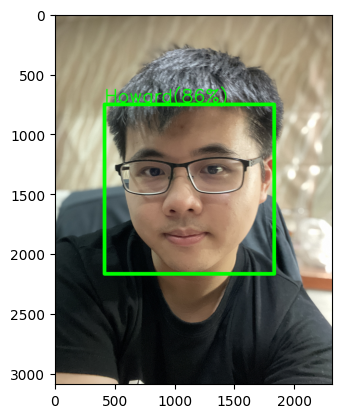

In [4]:
# 設定區
IMAGE_PATH = "sample/face_test/Howard/IMG_9250.jpg"

# 主程式執行
img = cv2.imread(IMAGE_PATH)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 使用 Haar Cascade 偵測人臉，用法如同第 20-2 節
faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

for (x, y, w, h) in faces:
    # 將裁切出的灰階人臉交給 LBPH 辨識，回傳預測 ID 與信心分數
    id, conf = recognizer.predict(gray[y:y+h, x:x+w])

    # LBPH 信心分數越低代表越相似，轉換為百分比較直覺
    name = id_to_name.get(id, "Unknown")
    text = f"{name}({100 - int(conf)}%)"

    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 30)
    cv2.putText(img, text, (x, y-20), cv2.FONT_HERSHEY_SIMPLEX, 5, (0, 255, 0), 10)

# 顯示結果
opencv_tools.show_img_by_matplotlib(img)

### 21-2-6 測試範例：使用 LBPH 方法進行人臉辨識 (多人)

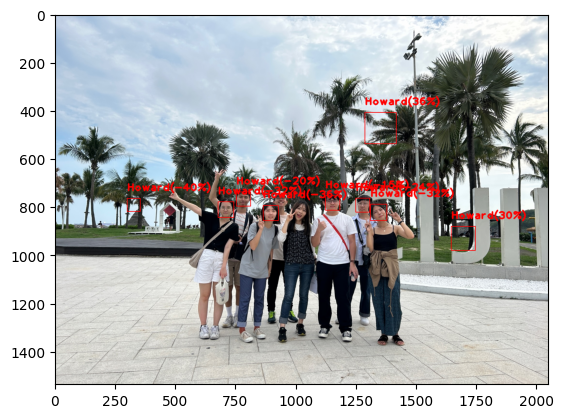

In [5]:
# 設定區
IMAGE_PATH = "sample/face_test/IMG_3941.jpg"

# 主程式執行 IMAGE_PATH
img = cv2.imread(IMAGE_PATH)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

result = img.copy()
for (x, y, w, h) in faces:
    # 將裁切出的灰階人臉交給 LBPH 辨識，回傳預測 ID 與信心分數
    id, conf = recognizer.predict(gray[y:y+h, x:x+w])
    
    # LBPH 信心分數越低代表越相似，轉換為百分比較直覺
    name = id_to_name.get(id, "Unknown")
    text = f"{name}({100 - int(conf)}%)"
    # 繪製方框與辨識結果
    cv2.rectangle(result, (x, y), (x+w, y+h), (0, 0, 255), 2)
    cv2.putText(result, text, (x, y-30), cv2.FONT_HERSHEY_PLAIN, 3, (0, 0, 255), 5)

# 顯示結果
opencv_tools.show_img_by_matplotlib(result)

### 21-2-7 儲存 LBPH 人臉辨識訓練結果

In [6]:
# --- 設定區 ---
TRAINER_DIR = "trainer"
TRAINER_YML_PATH = os.path.join(TRAINER_DIR, "trainer.yml")
NAMES_PKL_PATH = os.path.join(TRAINER_DIR, "names.pkl")

# 儲存訓練結果
os.makedirs(TRAINER_DIR, exist_ok=True)

# 儲存 LBPH 辨識器
recognizer.save(TRAINER_YML_PATH)

# 儲存 id_to_name 對應表
with open(NAMES_PKL_PATH, 'wb') as f:
    pickle.dump(id_to_name, f)

* 往後若需要載入已儲存的模型，只需執行以下程式碼即可直接使用，不需要重新訓練：

In [7]:
# recognizer = cv2.face.LBPHFaceRecognizer_create()
# recognizer.read(TRAINER_YML_PATH)
# with open(NAMES_PKL_PATH, 'rb') as f:
#     id_to_name = pickle.load(f)

### 21-3-4 前處理範例：從原始影像中擷取與對齊人臉

* 定義 preprocess_and_detect_face 函式，這個函式負責將原始影像進行縮放並偵測人臉位置 (此前處理函式訓練與推論共用)

In [8]:
# --- 設定區 ---
DET_MODEL_PATH = "models/face_detection_yunet_2023mar.onnx"
MIN_CONFIDENCE = 0.8  # 最低信心度門檻
MIN_FACE_WIDTH = 40   # 最小人臉寬度
RESIZE_WIDTH = 640    # 統一處理寬度

# --- 載入偵測模型 ---
detector = cv2.FaceDetectorYN.create(
    DET_MODEL_PATH, "", (0, 0), score_threshold=MIN_CONFIDENCE
)

# --- 前處理與偵測函式 ---
def preprocess_and_detect_face(image):
    # 將圖片縮放至固定寬度，加速偵測並符合模型輸入要求
    original_h, original_w = image.shape[:2]
    scale = RESIZE_WIDTH / original_w
    resized_h = int(original_h * scale)
    resized_img = cv2.resize(image, (RESIZE_WIDTH, resized_h))

    # 設定偵測器輸入尺寸並執行偵測
    detector.setInputSize((RESIZE_WIDTH, resized_h))
    _, faces = detector.detect(resized_img)
    if faces is None:
        return []

    # 將偵測座標還原回原圖比例，並過濾過小的人臉
    processed_faces = []
    for face in faces:
        face_on_original = face.copy()
        # 前 14 個數值為方框與五官特徵點座標，索引 14 為信心度，保持不變
        face_on_original[:14] /= scale
        if face_on_original[2] >= MIN_FACE_WIDTH:
            processed_faces.append(face_on_original)

    return processed_faces

* 使用 21-1-1 節已經先準備好的人臉訓練資料集，透過剛剛定義好的 preprocess_and_detect_face 函式進行人臉擷取與對齊。

In [9]:
# --- 設定區 ---
REC_MODEL_PATH = "models/face_recognition_sface_2021dec.onnx"
RAW_DATASET_PATH = "sample/face/"
PROCESSED_DATASET_PATH = "processed_face"

# --- 載入對齊模型 ---
recognizer = cv2.FaceRecognizerSF.create(REC_MODEL_PATH, "")

# --- 主程式執行 ---
# 先刪除舊資料夾再重建，確保每次執行的結果都是乾淨的
if os.path.exists(PROCESSED_DATASET_PATH):
    shutil.rmtree(PROCESSED_DATASET_PATH)
os.makedirs(PROCESSED_DATASET_PATH)

# 取得並排序所有人物資料夾，每個子資料夾代表一位人物
person_folders = sorted([
    d for d in os.listdir(RAW_DATASET_PATH)
    if os.path.isdir(os.path.join(RAW_DATASET_PATH, d))
])

for person_name in person_folders:
    person_raw_path = os.path.join(RAW_DATASET_PATH, person_name)
    person_processed_path = os.path.join(PROCESSED_DATASET_PATH, person_name)
    os.makedirs(person_processed_path, exist_ok=True)

    print(f"[INFO] 正在處理：{person_name}")

    image_names = [
        img for img in os.listdir(person_raw_path)
        if img.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    saved_count = 0
    for image_name in image_names:
        img = cv2.imread(os.path.join(person_raw_path, image_name))
        faces_list = preprocess_and_detect_face(img)

        if len(faces_list) == 1:
            # 依據五官特徵點將人臉旋轉校正並裁切成標準尺寸
            aligned_face = recognizer.alignCrop(img, faces_list[0])
            saved_count += 1
            # 補零命名確保檔案依序排列，例如 0001.jpg、0002.jpg
            save_path = os.path.join(person_processed_path, f"{str(saved_count).zfill(4)}.jpg")
            cv2.imwrite(save_path, aligned_face)
            print(f"  [PASS] {image_name}")
        elif len(faces_list) == 0:
            print(f"  [SKIP] {image_name}: 找不到人臉")
        else:
            print(f"  [SKIP] {image_name}: 偵測到 {len(faces_list)} 張臉，略過")

print("[INFO] 前處理完成！")

[INFO] 正在處理：.ipynb_checkpoints
[INFO] 正在處理：Howard
  [PASS] DSCF3851.JPG
  [PASS] DSCF4213.JPG
  [PASS] DSCF4895.JPG
  [PASS] IMG_3150.JPG
  [PASS] IMG_3207.JPG
  [PASS] IMG_4059.JPG
  [PASS] IMG_6085.jpg
  [PASS] IMG_6433.JPG
  [PASS] IMG_7015.JPG
  [PASS] IMG_8244.JPG
  [PASS] IMG_9559.JPG
  [PASS] IMG_9950.JPG
[INFO] 前處理完成！


### 21-3-6 訓練範例：根據前處理後的人臉，建立人臉特徵資料庫

In [10]:
# --- 設定區 ---
REC_MODEL_PATH = "models/face_recognition_sface_2021dec.onnx"
PROCESSED_DATASET_PATH = "processed_face"
DATABASE_PKL_PATH = "face_database.pkl"

# --- 載入 SFace 模型 ---
recognizer = cv2.FaceRecognizerSF.create(REC_MODEL_PATH, "")

# --- 建立特徵資料庫 ---
face_database = {}

person_folders = sorted([
    d for d in os.listdir(PROCESSED_DATASET_PATH)
    if os.path.isdir(os.path.join(PROCESSED_DATASET_PATH, d))
])

for person_name in person_folders:
    person_folder_path = os.path.join(PROCESSED_DATASET_PATH, person_name)
    print(f"[INFO] 正在處理：{person_name}")

    features = []
    for image_name in os.listdir(person_folder_path):
        aligned_face = cv2.imread(os.path.join(person_folder_path, image_name))
        # 對每張對齊人臉提取 128 維特徵向量
        feature = recognizer.feature(aligned_face)
        features.append(feature)

    # 將所有照片的特徵向量取平均，作為該人物的代表特徵
    face_database[person_name] = np.mean(features, axis=0)

# 儲存人臉辨識資料庫
with open(DATABASE_PKL_PATH, 'wb') as f:
    pickle.dump(face_database, f)

print(f"[INFO] 特徵資料庫已儲存至 {DATABASE_PKL_PATH}")

[INFO] 正在處理：.ipynb_checkpoints
[INFO] 正在處理：Howard


C:\Users\howard\anaconda3\envs\env_opencv_2\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\howard\anaconda3\envs\env_opencv_2\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[INFO] 特徵資料庫已儲存至 face_database.pkl


### 21-3-8 測試範例：使用 SFace 深度學習模型進行人臉辨識 (單人)

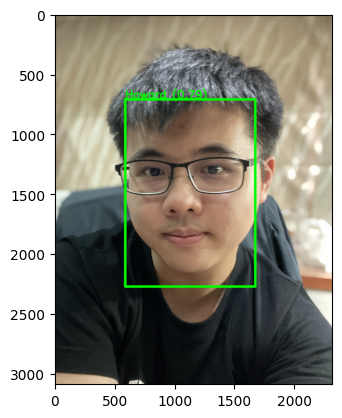

In [11]:
# 設定區
IMAGE_PATH = "sample/face_test/Howard/IMG_9250.jpg"
RECOGNITION_THRESHOLD = 0.363  # 相似度門檻，超過才視為辨識成功

# 讀取圖片並偵測人臉
test_image = cv2.imread(IMAGE_PATH)
result_image = test_image.copy()

# 呼叫前處理函式，回傳符合條件的人臉資料列表
faces_list = preprocess_and_detect_face(test_image)

# 逐一匹配每張人臉
for face in faces_list:
    # 對齊裁切後提取特徵向量
    aligned_face = recognizer.alignCrop(test_image, face)
    test_feature = recognizer.feature(aligned_face)

    # 與資料庫中每位人物的特徵向量計算相似度，取最高分
    best_match_name = "Unknown"
    highest_similarity = 0.0
    for name, db_feature in face_database.items():
        similarity = recognizer.match(test_feature, db_feature, cv2.FaceRecognizerSF_FR_COSINE)
        if similarity > highest_similarity:
            highest_similarity = similarity
            best_match_name = name

    # 超過門檻視為辨識成功，否則標記為 Unknown
    if highest_similarity >= RECOGNITION_THRESHOLD:
        result_text = f"{best_match_name} ({highest_similarity:.2f})"
        color = (0, 255, 0)   # 綠色：辨識成功
    else:
        result_text = f"Unknown ({highest_similarity:.2f})"
        color = (0, 0, 255)   # 紅色：辨識失敗

    # 繪製方框與辨識結果
    box = list(map(int, face[:4]))
    text_y = box[1] - 10 if box[1] - 20 > 10 else box[1] + box[3] + 30
    cv2.rectangle(result_image, (box[0], box[1]), (box[0] + box[2], box[1] + box[3]), color, 20)
    cv2.putText(result_image, result_text, (box[0], text_y), cv2.FONT_HERSHEY_SIMPLEX, 3, color, 10)

# 顯示結果
opencv_tools.show_img_by_matplotlib(result_image)

### 21-3-9 測試範例：使用 SFace 深度學習模型進行人臉辨識 (多人)

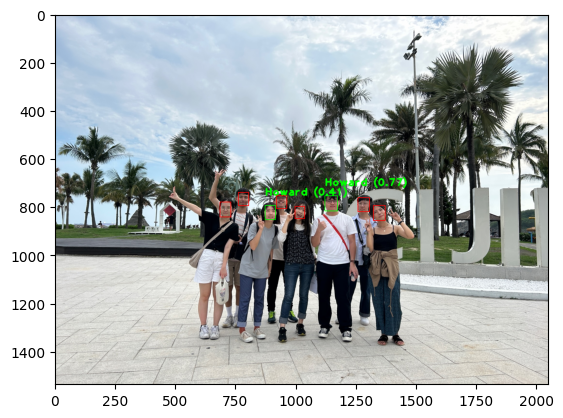

In [12]:
# 設定區
IMAGE_PATH = "sample/face_test/IMG_3941.jpg"
RECOGNITION_THRESHOLD = 0.363  # 相似度門檻，超過才視為辨識成功

# 讀取圖片並偵測人臉
test_image = cv2.imread(IMAGE_PATH)
result_image = test_image.copy()

# 呼叫前處理函式，回傳符合條件的人臉資料列表
faces_list = preprocess_and_detect_face(test_image)

# 逐一匹配每張人臉
for face in faces_list:
    # 對齊裁切後提取特徵向量
    aligned_face = recognizer.alignCrop(test_image, face)
    test_feature = recognizer.feature(aligned_face)

    # 與資料庫中每位人物的特徵向量計算相似度，取最高分
    best_match_name = "Unknown"
    highest_similarity = 0.0
    for name, db_feature in face_database.items():
        similarity = recognizer.match(test_feature, db_feature, cv2.FaceRecognizerSF_FR_COSINE)
        if similarity > highest_similarity:
            highest_similarity = similarity
            best_match_name = name

    # 超過門檻視為辨識成功，否則標記為 Unknown
    if highest_similarity >= RECOGNITION_THRESHOLD:
        result_text = f"{best_match_name} ({highest_similarity:.2f})"
        color = (0, 255, 0)   # 綠色：辨識成功
    else:
        result_text = f""     # Unknown
        color = (0, 0, 255)   # 紅色：辨識失敗

    # 繪製方框與辨識結果
    box = list(map(int, face[:4]))
    text_y = box[1] - 10 if box[1] - 20 > 10 else box[1] + box[3] + 30
    cv2.rectangle(result_image, (box[0], box[1]), (box[0] + box[2], box[1] + box[3]), color, 2)
    cv2.putText(result_image, result_text, (box[0], text_y-30), cv2.FONT_HERSHEY_PLAIN, 3, color, 5)

# 顯示結果
opencv_tools.show_img_by_matplotlib(result_image)

### 21-E 小專案：即時人臉辨識系統

* 共用前處理函式（與 20-E 完全相同）

In [13]:
def enhance_brightness(frame, alpha=1.2, beta=50):
    """調整影像的亮度與對比度，改善偏暗、層次不夠分明的問題。"""
    return cv2.convertScaleAbs(frame, alpha=alpha, beta=beta)

* LBPH 辨識函式 + 載入模型

In [14]:
# 載入 Haar Cascade + LBPH 模型（已訓練好的）
detector_haar = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
recognizer_lbph = cv2.face.LBPHFaceRecognizer_create()
recognizer_lbph.read("trainer/trainer.yml")

with open("trainer/names.pkl", 'rb') as f:
    id_to_name = pickle.load(f)


def recognize_lbph(frame):
    """使用 LBPH 進行即時人臉辨識"""
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = detector_haar.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
    
    for (x, y, w, h) in faces:
        id, conf = recognizer_lbph.predict(gray[y:y+h, x:x+w])
        name = id_to_name.get(id, "Unknown")
        text = f"{name}({100 - int(conf)}%)"
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(frame, text, (x, y-10), cv2.FONT_HERSHEY_PLAIN, 1.5, (0, 255, 0), 2)
    return frame

* SFace 辨識函式 + 載入模型

In [15]:
# 載入 YuNet + SFace 模型（特徵資料庫已建立好）
detector_yunet = cv2.FaceDetectorYN.create("models/face_detection_yunet_2023mar.onnx", "", (0, 0))
recognizer_sface = cv2.FaceRecognizerSF.create("models/face_recognition_sface_2021dec.onnx", "")

with open("face_database.pkl", 'rb') as f:
    face_database = pickle.load(f)


def recognize_sface(frame, threshold=0.363):
    """使用 SFace 進行即時人臉辨識"""
    h, w = frame.shape[:2]
    detector_yunet.setInputSize((w, h))
    _, faces = detector_yunet.detect(frame)
    
    if faces is None:
        return frame
    
    for face in faces:
        aligned_face = recognizer_sface.alignCrop(frame, face)
        test_feature = recognizer_sface.feature(aligned_face)
        
        best_match_name = "Unknown"
        highest_similarity = 0.0
        for name, db_feature in face_database.items():
            similarity = recognizer_sface.match(test_feature, db_feature, cv2.FaceRecognizerSF_FR_COSINE)
            if similarity > highest_similarity:
                highest_similarity = similarity
                best_match_name = name
        
        if highest_similarity >= threshold:
            text = f"{best_match_name} ({highest_similarity:.2f})"
            color = (0, 255, 0)
        else:
            text = ""
            color = (0, 0, 255)
        
        box = list(map(int, face[:4]))
        cv2.rectangle(frame, (box[0], box[1]), (box[0]+box[2], box[1]+box[3]), color, 2)
        cv2.putText(frame, text, (box[0], box[1]-10), cv2.FONT_HERSHEY_PLAIN, 1.5, color, 2)
    return frame

* 主程式（透過註解切換人臉辨識方法）

In [16]:
cap = cv2.VideoCapture(0)
# cap = cv2.VideoCapture("sample/video/me2.mp4")  # 影片測試
# cap = cv2.VideoCapture("sample/video/me3.mp4")  # 影片測試

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    # 前處理（視測試需求決定是否啟用）
    # frame = enhance_brightness(frame)
    
    # 切換人臉辨識方法（註解/取消註解切換）
    frame = recognize_lbph(frame)
    # frame = recognize_sface(frame)
    
    cv2.imshow('Face Recognition', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()